# DATA MINING ANALYTICS-ASSIGNMENT02
### Answers to Question 1, 2, and 3

In [29]:
# import libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import yfinance as yf


## Question 1: Diabetes Data Analysis

### 1.1: Loading the data and correlation analysis

In [4]:
# load diabetes dataset
df = pd.read_csv(r"C:\Users\PACKS\Downloads\Diabetes_Data (2).csv")
X = df.iloc[:, :-1]


In [5]:


#correlation matrix
corr_matrix = X.corr()  


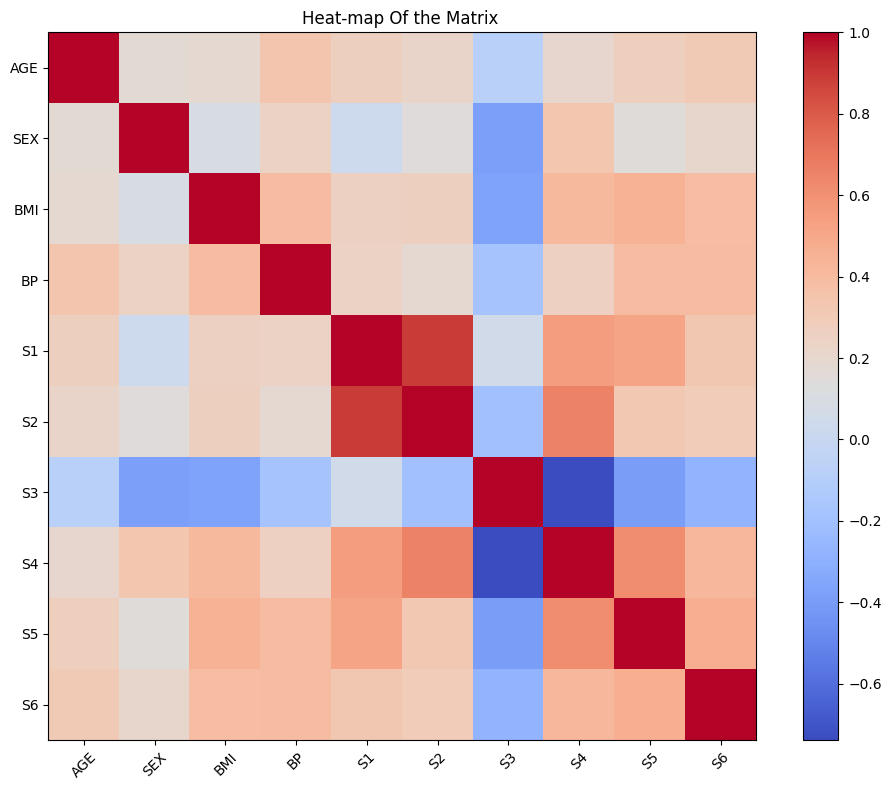

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6
AGE,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
SEX,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
BMI,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
BP,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
S1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
S2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
S3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
S4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
S5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
S6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


In [12]:

# Heat-map of matrix
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(X.columns)), X.columns, rotation=45)
plt.yticks(range(len(X.columns)), X.columns)
plt.title('Heat-map Of the Matrix ')
plt.tight_layout()
plt.show()
corr_matrix

### 1.3.Multivariate Linear Regression

In [13]:
# Add constant
X_const = sm.add_constant(X)


In [ ]:
# Fit model
model = sm.OLS(df['Y'], X_const).fit()


In [25]:
# Predictions and metrics
y_pred = model.predict(X_const)

mse = mean_squared_error(df['Y'], y_pred)
adj_r2 = model.rsquared_adj

print(f"Mean Squared Error (MSE) Is  {mse:.4f}")
print(f"Adjusted R² Is {adj_r2:.4f}")


Mean Squared Error (MSE) Is  2859.6963
Adjusted R² Is 0.5066


## Question 2: Titanic Data Analysis

### 2.2: Load titanic data and survival probability

In [18]:
# Load titanic dataset
titanic = pd.read_csv(r"C:\Users\PACKS\Downloads\titanic3 (1).csv")

      

In [19]:
# select relevant variables
titanic = titanic[['survived', 'pclass', 'sex', 'age']].dropna()
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
X = titanic[['pclass', 'sex', 'age']]
y = titanic['survived']

In [20]:
# Train logistic regression model
log_model = LogisticRegression()
log_model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
# survival probabilities
titanic['survival_prob'] = log_model.predict_proba(X)[:, 1]
titanic.head() 


,survived,pclass,sex,age,survival_prob
0,1,1,1,29.00,0.917194
1,1,1,0,0.92,0.713857
2,0,1,1,2.00,0.964604
3,0,1,0,30.00,0.486137
4,0,1,1,25.00,0.926776


### 2.3: Survival probability by class, gender, and age

In [23]:
survival_table = titanic.groupby( ['pclass', 'sex', 'age'])['survived'].mean().reset_index()
survival_table


,pclass,sex,age,survived
0,1,0,0.92,1.0
1,1,0,4.00,1.0
2,1,0,6.00,1.0
3,1,0,11.00,1.0
4,1,0,13.00,1.0
...,...,...,...,...
327,3,1,43.00,0.0
328,3,1,45.00,0.4
329,3,1,47.00,0.5
330,3,1,48.00,0.0


### 2.4 Logistic regression parameter

In [24]:
# Coefficients
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': log_model.coef_[0]
})
coefficients

,Variable,Coefficient
0,pclass,-1.110151
1,sex,2.426937
2,age,-0.033344


**Interpretation:**                                               
Passenger class, sex, and age significantly influenced survival probability

### 2.5 Model performance

In [74]:
# Predictions and confusion matrix
y_pred_class = log_model.predict(X)
cm = confusion_matrix(y, y_pred_class)
acc = accuracy_score(y, y_pred_class)

cm, acc

(array([[524,  95],
        [127, 300]]),
 0.7877629063097514)

## Question 3: Principal Component Analysis (PCA)

### 3.3: Dow Jones Constituent Stocks

In [54]:
# Dow Jones stocks 
tickers = [
    'MMM', 'AXP', 'AMGN', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 'KO',
    'DIS', 'DOW', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM',
    'MCD', 'MRK', 'MSFT', 'NKE', 'PG', 'CRM', 'TRV', 'UNH',
    'VZ', 'V', 'AMZN', 'WMT'
]


In [50]:

# Download adjusted close prices
data = yf.download(
    tickers=tickers,
    start="2020-01-01",
    end="2021-01-01",
    auto_adjust=True
)


[*********************100%***********************]  30 of 30 completed


In [51]:

# Extract closing prices
prices = data['Close']


In [52]:

# Compute daily returns
returns = prices.pct_change().dropna()

returns.head()


Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MMM,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,-0.009722,-0.006789,-0.012139,-0.009932,-0.001680,-0.013884,-0.004911,-0.016315,-0.003459,-0.011471,...,-0.008611,-0.008583,-0.012452,-0.002740,-0.006726,-0.003563,-0.010120,-0.007953,-0.010647,-0.008828
2020-01-06,0.007968,0.007674,0.014886,-0.004334,0.002945,-0.000674,0.043811,0.003569,-0.003388,-0.005802,...,0.000952,0.004274,0.002585,-0.000883,0.001387,0.001095,0.006942,-0.002163,-0.002152,-0.002036
2020-01-07,-0.004703,-0.009405,0.002092,-0.005239,0.010607,-0.013213,0.014702,-0.006485,-0.012770,0.000343,...,-0.004031,-0.026626,-0.009118,-0.000491,-0.006192,-0.014653,-0.006037,-0.002643,-0.011117,-0.009265
2020-01-08,0.016086,0.000756,-0.007809,0.017260,-0.017523,0.008881,0.007557,0.000632,-0.011423,-0.002059,...,0.015346,-0.006726,0.015928,-0.002260,0.004263,0.010728,0.021084,0.017118,0.001846,-0.003431
2020-01-09,0.021241,0.002980,0.004799,0.018082,0.014998,-0.002505,0.012801,-0.004209,-0.001614,-0.003920,...,0.003156,0.008804,0.012493,-0.000689,0.010938,0.007393,-0.005677,0.006930,-0.004146,0.010330


In [53]:
# Standardize returns
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)


In [40]:

# PCA
pca = PCA()
pca.fit(returns_scaled)


,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [41]:

# Eigenvectors (loadings)
loadings = pca.components_


In [42]:

# Explained variance
explained_variance = pca.explained_variance_ratio_


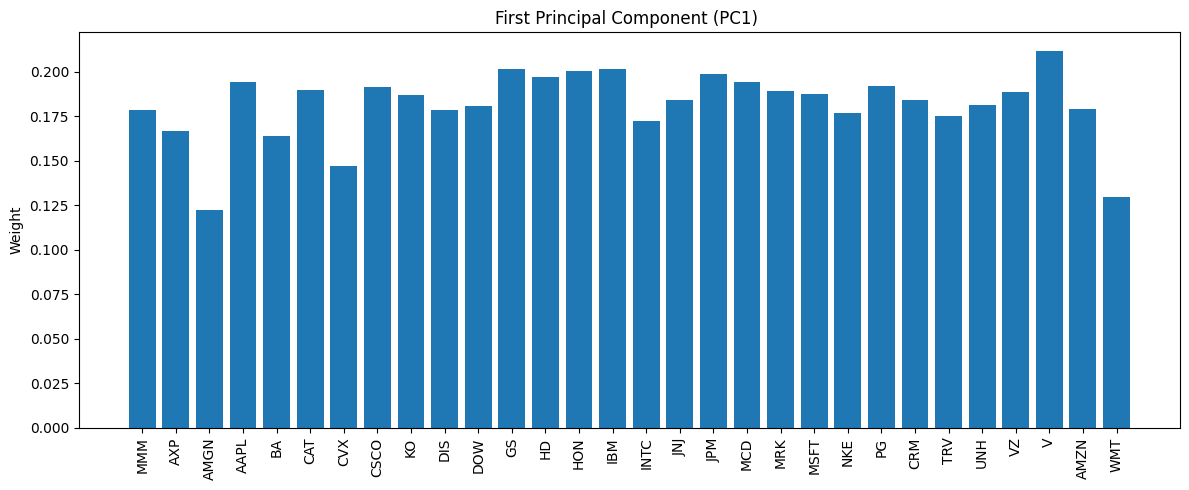

In [45]:
#Plot First Principal Component (PC1)
plt.figure(figsize=(12, 5))
plt.bar(tickers, loadings[0])
plt.xticks(rotation=90)
plt.title("First Principal Component (PC1) ")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()


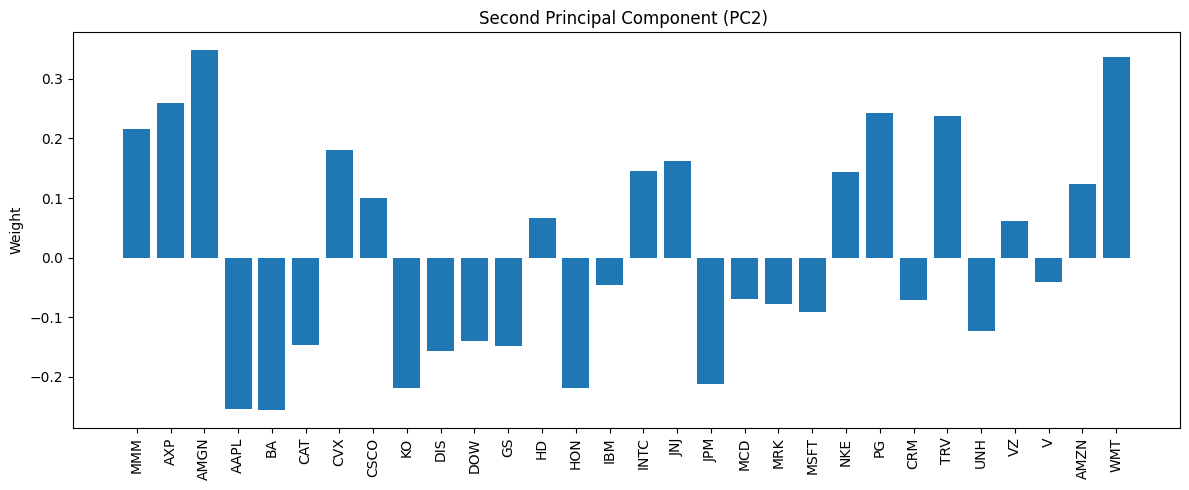

In [46]:
#Plot Second Principal Component (PC2)
plt.figure(figsize=(12, 5))
plt.bar(tickers, loadings[1])
plt.xticks(rotation=90)
plt.title("Second Principal Component (PC2) ")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()


**Interpretation of the graph**  
-First principal component (PC1 bar graph) is mostly show the same sign and similar size which represents market movement but Second principal component (PC2 bar graph) is not similar to the market (equal weight on each stock) because bars have positive and negative values which represents differences between stocks/sectors

In [55]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_


In [56]:

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)


In [62]:
# Display amunt of variance explained by each PC
pc_df = pd.DataFrame({
    'PC': range(1, len(explained_variance)+1),
    'Variance_Explained': np.round(explained_variance, 4),
    'Cumulative': np.round(cumulative_variance, 4)
})
print(pc_df)

    PC  Variance_Explained  Cumulative
0    1              0.6140      0.6140
1    2              0.0861      0.7001
2    3              0.0445      0.7446
3    4              0.0252      0.7698
4    5              0.0232      0.7930
5    6              0.0198      0.8127
6    7              0.0179      0.8307
7    8              0.0167      0.8474
8    9              0.0144      0.8618
9   10              0.0140      0.8758
10  11              0.0115      0.8873
11  12              0.0104      0.8977
12  13              0.0098      0.9075
13  14              0.0094      0.9169
14  15              0.0086      0.9255
15  16              0.0083      0.9338
16  17              0.0078      0.9416
17  18              0.0073      0.9489
18  19              0.0067      0.9556
19  20              0.0062      0.9617
20  21              0.0056      0.9674
21  22              0.0052      0.9726
22  23              0.0047      0.9773
23  24              0.0044      0.9817
24  25              0.004

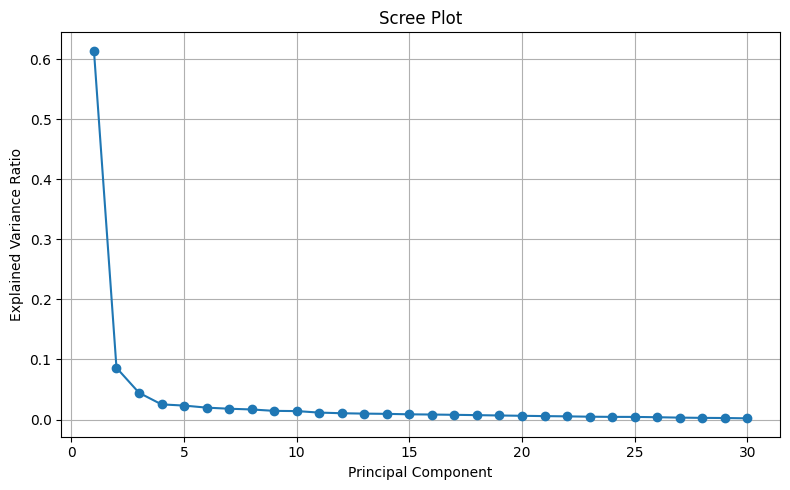

In [64]:
# scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.tight_layout()
plt.show()


In [65]:
# Principal component required to explain 95% variance
num_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
num_components_95



np.int64(19)

## 3.5: Outlier Stocks Using PCA

In [66]:
# Project returns onto principal components
pc_scores = pca.transform(returns_scaled)

# Create DataFrame for first two PCs
pc_df = pd.DataFrame(
    pc_scores[:, :2],
    columns=['PC1', 'PC2'],
    index=returns.index
)

In [72]:
# Transpose loadings to align with stocks
stock_pcs = pd.DataFrame(
    pca.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=tickers
)

# Average position (mean of all stocks)
mean_pc = stock_pcs.mean()
mean_pc


PC1    0.181519
PC2    0.011574
dtype: float64

In [73]:
# Euclidean distance from the mean
stock_pcs['Distance'] = np.sqrt(
    (stock_pcs['PC1'] - mean_pc['PC1'])**2 +
    (stock_pcs['PC2'] - mean_pc['PC2'])**2
)

# Identify three most distant stocks
most_distant = stock_pcs.sort_values('Distance', ascending=False).head(3)
most_distant


,PC1,PC2,Distance
AMGN,0.122260,0.348086,0.34169
WMT,0.129537,0.336381,0.32894
BA,0.163840,-0.255451,0.26761


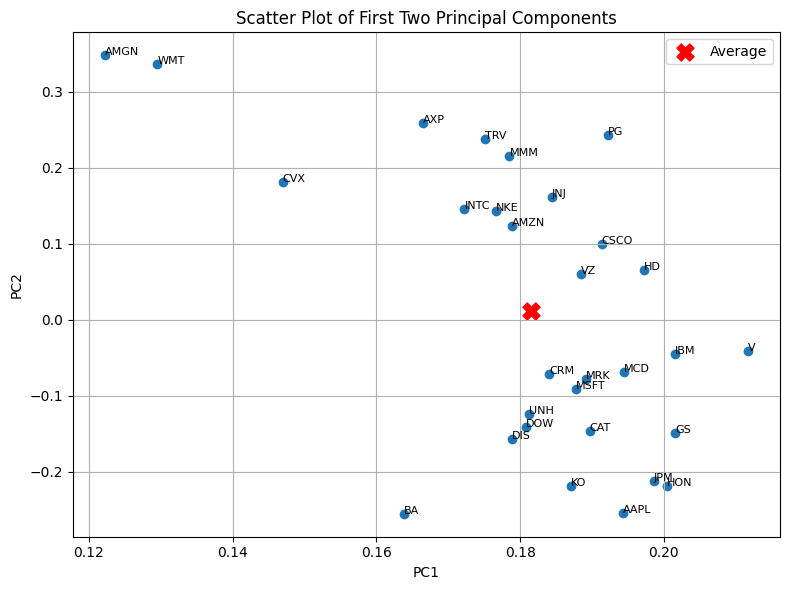

In [79]:
# Scatter plot of first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(stock_pcs['PC1'], stock_pcs['PC2'])


# Plot average point
plt.scatter(mean_pc['PC1'], mean_pc['PC2'], color='red', marker='X', s=150, label='Average')


# Annotate stock names
for stock in stock_pcs.index:
    plt.text(stock_pcs.loc[stock, 'PC1'],
             stock_pcs.loc[stock, 'PC2'],
             stock,
             fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Scatter Plot of First Two Principal Components")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





**The stocks are unusual because:-**     
These stocks experienced sector-specific shocks and non-typical return behavior, making them distant from the average Dow Jones stock in PCA space.